# Evidential Deep Learning - Digit Classification

This notebook is based on *Evidential Deep Learning to Quantify Classification Uncertainty* (Sensoy et al., 2018): https://arxiv.org/abs/1806.01768

Evidential Deep Learning (EDL) lets a neural network model both class predictions and predictive uncertainty by treating outputs as parameters of a higher-order distribution.
Instead of returning only a point estimate, the model can represent both **what it believes** and **how strongly it believes it**.

In this notebook, we apply EDL to image classification on **FashionMNIST** and compare it with a standard softmax classifier, including out-of-distribution behavior on CIFAR-10.

In [1]:
%matplotlib widget

import torch
import matplotlib.pyplot as plt
import numpy as np
from util import show_images, SoftmaxBrowser, InteractiveDirichlet, EDLBrowser
from training import edl_loss, train
import torch.nn.functional as F
from torch import nn
import warnings
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms as T
import os

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

## Dataset Setup

In this section, we prepare two datasets for the experiments:

- **FashionMNIST (in-distribution)**: used for training and standard evaluation.
- **CIFAR-10 (out-of-distribution)**: used to test how the model behaves on data outside the training distribution.

For FashionMNIST, we apply light data augmentation on the training split  to improve robustness.

For CIFAR-10, we convert images to grayscale and resize them to $28 \times 28$ so they are shape-compatible with the FashionMNIST-trained model.

In [2]:
fashion_train_transform = T.Compose(
    [
        T.RandomHorizontalFlip(),
        T.RandomResizedCrop(28, scale=(0.7, 1.0)),
        T.ToTensor(),
    ]
)
fashion_train_set = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=fashion_train_transform
)
fashion_test_set = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=T.ToTensor()
)
fashion_loader_train = DataLoader(
    fashion_train_set,
    batch_size=256,
    shuffle=True,
    num_workers=(os.cpu_count() or 2) - 1,
)
fashion_loader_test = DataLoader(
    fashion_test_set, batch_size=256, shuffle=False, num_workers=2
)
fashion_classes = fashion_train_set.classes

cifar_transform = T.Compose(
    [
        T.Grayscale(num_output_channels=1),  # Convert to grayscale
        T.Resize((28, 28)),  # Resize to match MNIST dimensions
        T.ToTensor(),
    ]
)
cifar_test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=cifar_transform
)
cifar_loader_test = DataLoader(
    cifar_test_set, batch_size=32, shuffle=True, num_workers=2
)

Let's take a look at a few examples of the FashionMNIST dataset.

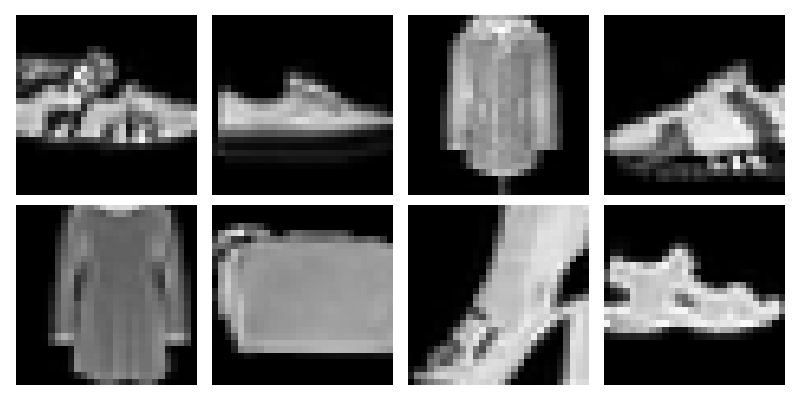

In [3]:
show_images(fashion_loader_train, n_images=8);

### The Traditional Approach

In standard image classification, a neural network (often a CNN) maps an input image to a vector of **logits**.
Logits are unnormalized class scores: larger values indicate classes the model considers more plausible, but logits themselves are not probabilities.

To convert logits into a valid probability distribution, we apply **Softmax**.
For logits $z$, the predicted probability for class $i$ is:

$$P(y=i \mid z)=\frac{e^{z_i}}{\sum_j e^{z_j}}$$

Model training then uses **Cross-Entropy Loss**, which compares predicted probabilities with the true one-hot label.
For a 10-class problem, the loss is:

$$L=-\sum_{i=1}^{10} y_i\log(\hat{y}_i)$$

Minimizing this loss through backpropagation and an optimizer (for example Adam) pushes probability mass toward the correct class and improves classification accuracy over time.

### Training

We now train a baseline softmax classifier on FashionMNIST.
The goal is to establish a strong reference model before introducing the evidential variant.
After training, we will inspect both in-distribution predictions and behavior on out-of-distribution inputs.

In [4]:
class TraditionalModel(nn.Module):
    def __init__(
        self,
        num_classes=10,
        dropout_rate=0.3,
        learning_rate=5e-3,
        warmup_epochs=1,
        width_factor=1.0,
    ):
        super().__init__()
        self.learning_rate = learning_rate
        self.warmup_epochs = warmup_epochs
        self.model = nn.Sequential(
            # learn the mean/std of the dataset
            nn.BatchNorm2d(1),
            # Block 1: 28x28 -> 14x14
            nn.Conv2d(1, int(32 * width_factor), kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(int(32 * width_factor)),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(dropout_rate),
            # Block 2: 14x14 -> 7x7
            nn.Conv2d(
                int(32 * width_factor),
                int(32 * width_factor),
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(int(32 * width_factor)),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(dropout_rate),
            # Fully Connected
            nn.Flatten(),
            nn.Linear(int(32 * width_factor) * 7 * 7, int(128 * width_factor)),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(int(128 * width_factor), num_classes),
        )

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, **_kwargs):
        images, labels = batch
        logits = self(images)
        loss = F.cross_entropy(logits, labels)  # computes softmax internally
        return loss

    def configure_optimizer(self, steps_per_epoch, epochs):
        max_lr = self.learning_rate
        total_steps = steps_per_epoch * epochs
        warmup_steps = int(self.warmup_epochs * steps_per_epoch)

        optimizer = torch.optim.Adam(self.parameters(), lr=max_lr)

        # 1. Linear Warmup: Start near 0, go to max_lr
        warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_steps
        )

        # 2. Cosine Decay: Go from max_lr down to almost 0
        decay_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=(total_steps - warmup_steps)
        )

        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[warmup_scheduler, decay_scheduler],
            milestones=[warmup_steps],
        )

        return optimizer, scheduler


# Feel free to adjust these hyperparameters for better performance or faster training
LEARNING_RATE = 5e-3
EPOCHS = 5
WIDTH_FACTOR = 1.0  # Adjust this to make the model wider (more parameters) or narrower (faster training)


model_traditional = TraditionalModel(
    learning_rate=LEARNING_RATE, width_factor=WIDTH_FACTOR
)
train(model_traditional, fashion_loader_train, fashion_loader_test, epochs=EPOCHS)
model_traditional.eval();

Epoch 1/5: 100%|██████████| 235/235 [00:20<00:00, 11.66batch/s, loss=0.806, lr=0.005]  


Validation Accuracy: 80.99%


Epoch 2/5: 100%|██████████| 235/235 [00:20<00:00, 11.63batch/s, loss=0.564, lr=0.00427]


Validation Accuracy: 87.01%


Epoch 3/5: 100%|██████████| 235/235 [00:20<00:00, 11.60batch/s, loss=0.485, lr=0.0025] 


Validation Accuracy: 87.34%


Epoch 4/5: 100%|██████████| 235/235 [00:20<00:00, 11.75batch/s, loss=0.441, lr=0.000732]


Validation Accuracy: 88.11%


Epoch 5/5: 100%|██████████| 235/235 [00:20<00:00, 11.60batch/s, loss=0.421, lr=0]       


Validation Accuracy: 88.70%


After only a few epochs, the baseline model already reaches solid validation performance on FashionMNIST.
Next, we inspect individual predictions to understand confidence behavior on both in-distribution and out-of-distribution samples.

## Evaluation

In this section, we inspect predictions from the trained baseline model on FashionMNIST test samples.
Use the interactive viewer to step through examples and compare three signals:

- the input image,
- the raw logits
- the normalized softmax probabilities.

A well-calibrated prediction usually shows one clearly dominant class probability, while ambiguous samples tend to produce flatter probability distributions.

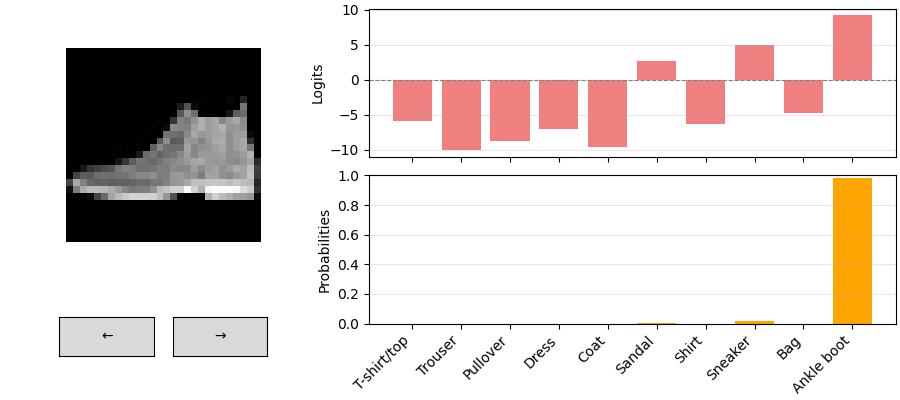

In [5]:
dataiter = iter(fashion_loader_test)
images, _ = next(dataiter)

plt.close()
browser = SoftmaxBrowser(images, model_traditional, class_names=fashion_classes)

## Noisy Data Behavior

Before testing true out-of-distribution samples, we stress the model with controlled Gaussian noise on in-distribution FashionMNIST images.
Use the slider to increase noise strength and observe how logits and softmax probabilities shift.
The model is re-evaluated every time the slider or image index changes.

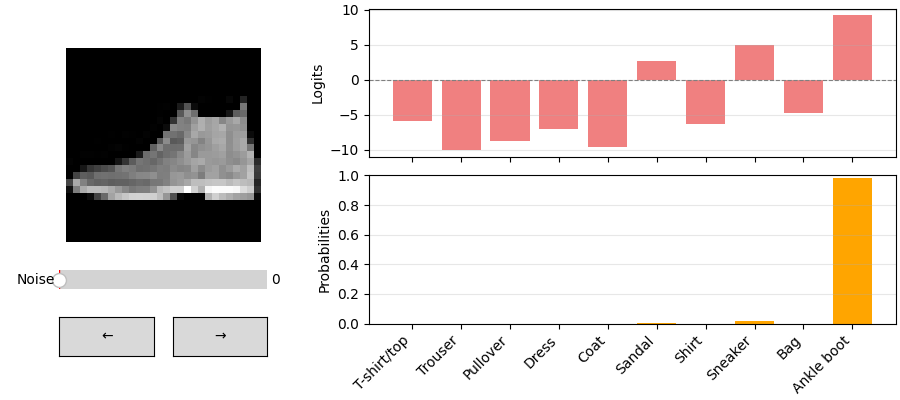

In [6]:
dataiter = iter(fashion_loader_test)
images, _ = next(dataiter)

plt.close()
browser = SoftmaxBrowser(
    images, model_traditional, class_names=fashion_classes, with_noise=True
)

## Out-of-Distribution Behavior

We now evaluate the same classifier on CIFAR-10 images, which are outside the FashionMNIST training distribution.
This helps reveal a key limitation of standard softmax models: they can produce very confident predictions even when the input is unfamiliar.

As you step through samples, look for cases where one class probability is sharply peaked despite the image not matching any FashionMNIST class well.

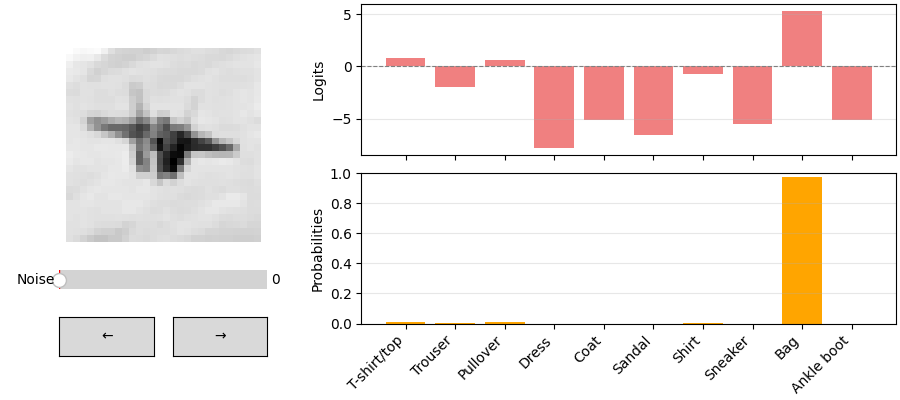

In [7]:
dataiter = iter(cifar_loader_test)
images, _ = next(dataiter)

plt.close()
browser = SoftmaxBrowser(
    images, model_traditional, class_names=fashion_classes, with_noise=True
)

## Evidential Deep Learning Approach

Evidential Deep Learning (EDL) predicts parameters of a **Dirichlet distribution** instead of only a softmax probability vector.
For a $K$-class problem, the model outputs $\alpha = [\alpha_1, \ldots, \alpha_K]$, where each $\alpha_k$ represents the amount of evidence supporting class $k$.

Intuitively:

- If one $\alpha_k$ is high and the others are low, the model expresses a confident preference for one class.
- If all $\alpha_k$ values are low, evidence is weak and the model should reflect high uncertainty.
- If multiple $\alpha_k$ values are high, the model indicates ambiguity between several plausible classes.


**Interactive Dirichlet Intuition**

In the next cell, you can adjust $\alpha_1$, $\alpha_2$, and $\alpha_3$ with sliders to see how the Dirichlet density changes over the simplex.

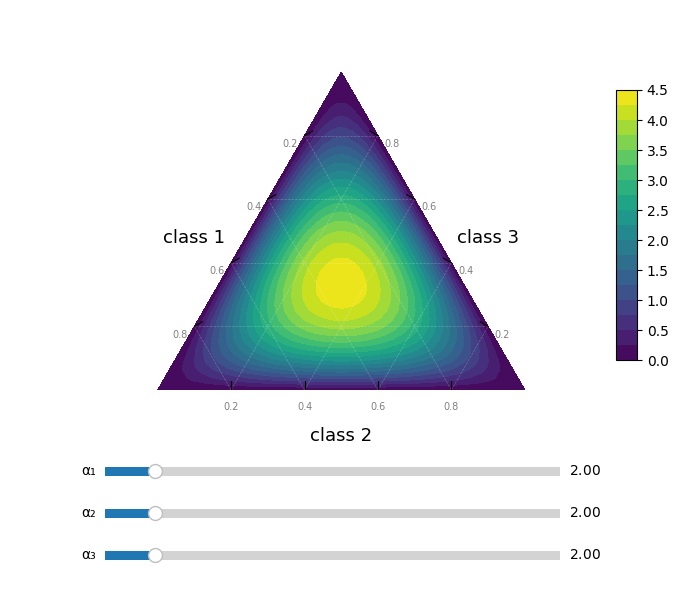

In [8]:
plt.close()
browser = InteractiveDirichlet()
plt.show()

To obtain valid Dirichlet parameters from network outputs, we use the following mapping:

### From Logits to Dirichlet

1. **Evidence**: $e_k = \mathrm{softplus}(\mathrm{logit}_k)$
Softplus ensures non-negative evidence, which is required for the Dirichlet parameterization.

2. **Add a unit prior**: $\alpha_k = e_k + 1$
The $+1$ term corresponds to a uniform prior (no class preference) when evidence is near zero.

### EDL Loss Function

For training, we optimize a loss composed of an evidence-aware data-fit term and a regularizer.
Define:

- **Total strength**: $S = \sum_{k=1}^K \alpha_k$
- **Expected class probability**: $\hat{p}_k = \alpha_k / S$

**1. MSE-based term**

$$\mathcal{L}_{\mathrm{MSE}} = \sum_{k=1}^K (y_k - \hat{p}_k)^2 + \sum_{k=1}^K \frac{\hat{p}_k(1-\hat{p}_k)}{S+1}$$

- The first part is an **accuracy term** that pushes expected probabilities toward the one-hot label.
- The second part is an **uncertainty/variance term**; as $S$ grows, this term decreases, encouraging evidence accumulation when justified by data.

**2. KL regularization term**

$$\mathcal{L}_{\mathrm{KL}} = \mathrm{KL}[\mathrm{Dir}(\tilde{\alpha})\,\|\,\mathrm{Dir}(\mathbf{1})]$$

with

$$\tilde{\alpha}_k = y_k + (1-y_k)\,\alpha_k$$

This construction preserves the target class at 1 while penalizing unnecessary evidence for non-target classes.

**3. Annealed total objective**

$$\mathcal{L} = \mathcal{L}_{\mathrm{MSE}} + \gamma\,\lambda(t)\,\mathcal{L}_{\mathrm{KL}}, \quad \lambda(t)=\min\!\left(1,\frac{t}{10}\right)$$

where $t$ is the epoch and $\gamma$ controls KL strength.

Annealing starts KL influence small and increases it gradually, allowing stable evidence learning early in training.

In [16]:
class EDLModel(nn.Module):
    def __init__(
        self,
        num_classes=10,
        dropout_rate=0.3,
        learning_rate=5e-3,
        warmup_epochs=1,
        width_factor=1.0,
    ):
        super().__init__()
        self.learning_rate = learning_rate
        self.warmup_epochs = warmup_epochs
        self.model = nn.Sequential(
            # learn the mean/std of the dataset
            nn.BatchNorm2d(1),
            # Block 1: 28x28 -> 14x14
            nn.Conv2d(1, int(32 * width_factor), kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(int(32 * width_factor)),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(dropout_rate),
            # Block 2: 14x14 -> 7x7
            nn.Conv2d(
                int(32 * width_factor),
                int(32 * width_factor),
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(int(32 * width_factor)),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(dropout_rate),
            # Fully Connected
            nn.Flatten(),
            nn.Linear(int(32 * width_factor) * 7 * 7, int(128 * width_factor)),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(int(128 * width_factor), num_classes),
            nn.Softplus(),  # ensures that the output is positive
        )

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, epoch, **_kwargs):
        images, labels = batch
        evidence = self(images)
        alpha = evidence + 1

        # includes KL divergence regularization term and annealing coefficient
        loss = edl_loss(alpha, labels, epoch, num_classes=10, gamma=0.1)

        return loss

    def configure_optimizer(self, steps_per_epoch, epochs):
        max_lr = self.learning_rate
        total_steps = steps_per_epoch * epochs
        warmup_steps = int(self.warmup_epochs * steps_per_epoch)

        optimizer = torch.optim.Adam(self.parameters(), lr=max_lr)

        # 1. Linear Warmup: Start near 0, go to max_lr
        warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_steps
        )

        # 2. Cosine Decay: Go from max_lr down to almost 0
        decay_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=(total_steps - warmup_steps)
        )

        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[warmup_scheduler, decay_scheduler],
            milestones=[warmup_steps],
        )

        return optimizer, scheduler


# Feel free to adjust these hyperparameters for better performance or faster training
EPOCHS = 10
LEARNING_RATE = 5e-3
WIDTH_FACTOR = 0.25


model_edl = EDLModel(learning_rate=LEARNING_RATE, width_factor=WIDTH_FACTOR)
train(model_edl, fashion_loader_train, fashion_loader_test, epochs=EPOCHS)
model_edl.eval();

Epoch 1/10: 100%|██████████| 235/235 [00:06<00:00, 36.74batch/s, loss=0.694, lr=0.005]  


Validation Accuracy: 69.40%


Epoch 2/10: 100%|██████████| 235/235 [00:05<00:00, 39.60batch/s, loss=0.535, lr=0.00485]


Validation Accuracy: 68.74%


Epoch 3/10: 100%|██████████| 235/235 [00:05<00:00, 39.47batch/s, loss=0.525, lr=0.00442]


...

Validation Accuracy: 57.48%


Epoch 9/10: 100%|██████████| 235/235 [00:06<00:00, 39.01batch/s, loss=0.565, lr=0.000151]


Validation Accuracy: 57.26%


Epoch 10/10: 100%|██████████| 235/235 [00:06<00:00, 35.45batch/s, loss=0.569, lr=0]      


Validation Accuracy: 56.02%


### Evaluate EDL Model

Now we inspect predictions from the trained EDL model on FashionMNIST test samples.
In the interactive viewer, focus on how evidence is allocated across classes and how that translates into expected probabilities.

Compared with softmax-only outputs, EDL gives an additional uncertainty signal through total evidence:

- concentrated evidence on one class suggests a confident prediction
- low overall evidence indicates uncertainty
- evidence spread across multiple classes reflects ambiguity between plausible labels

## Uncertainty Measures

Evidential Deep Learning separates different kinds of uncertainty by predicting Dirichlet parameters instead of only class probabilities.
This makes it possible to inspect both how much evidence the model has seen and how concentrated that evidence is across classes.

### 1. Vacuity
Vacuity measures how little evidence the model has overall. It is a simple proxy for epistemic uncertainty and is especially useful for out-of-distribution detection.

$$u = \frac{K}{S}$$

- $K$ is the number of classes.
- $S = \sum_k \alpha_k$ is the total strength.
- If the evidence is near zero, then $\alpha_k \approx 1$ and vacuity approaches 1.

### 2. Predictive Entropy
Predictive entropy measures uncertainty in the expected class probabilities.
It captures both lack of knowledge and class ambiguity.

$$\mathcal{H}(\hat{\mathbf{p}}) = -\sum_{k=1}^K \hat{p}_k \log(\hat{p}_k)$$

- This is high when the model is unsure overall.
- It can also be high when multiple classes look similarly plausible.

### 3. Expected Entropy
Expected entropy measures the average entropy under the Dirichlet distribution.
It is a more direct view of data uncertainty, or aleatoric uncertainty.

$$\mathbb{E}_{\mathbf{p} \sim \text{Dir}(\boldsymbol{\alpha})}[\mathcal{H}(\mathbf{p})] = -\sum_{k=1}^K \frac{\alpha_k}{S} \left( \psi(\alpha_k + 1) - \psi(S + 1) \right)$$

- $\psi$ is the digamma function.
- This term is driven by ambiguity in the data itself.

### 4. Mutual Information
Mutual information isolates epistemic uncertainty by subtracting expected entropy from predictive entropy.

$$\mathcal{I} = \mathcal{H}(\hat{\mathbf{p}}) - \mathbb{E}_{\mathbf{p} \sim \text{Dir}(\boldsymbol{\alpha})}[\mathcal{H}(\mathbf{p})]$$

- Large values indicate that the model would benefit from more information.
- This is commonly used in active learning.

### 5. Expected Variance
The Dirichlet form also gives a variance estimate for each class probability.

$$\text{Var}(p_k) = \frac{\alpha_k(S - \alpha_k)}{S^2(S + 1)} = \frac{\hat{p}_k(1 - \hat{p}_k)}{S + 1}$$

- This acts like an uncertainty band around the expected probability.
- As total evidence $S$ grows, the variance shrinks.


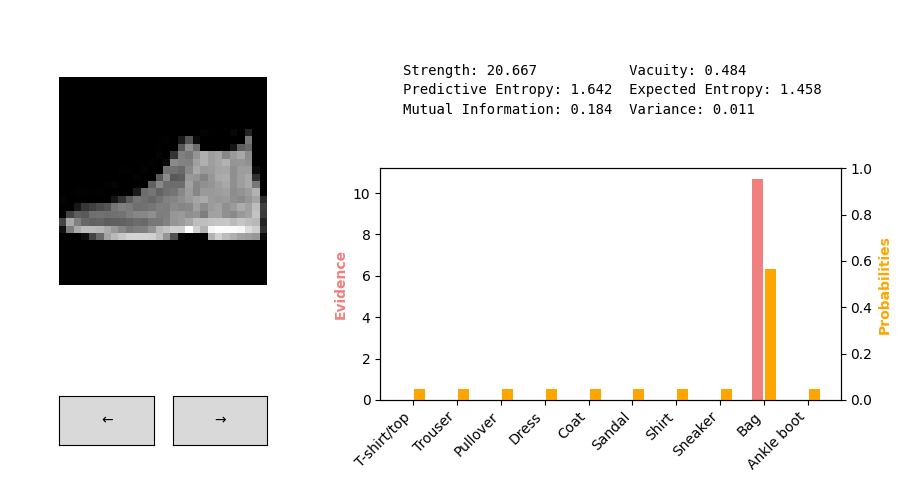

In [17]:
dataiter = iter(fashion_loader_test)
images, labels = next(dataiter)

plt.close()
browser = EDLBrowser(images, model_edl, class_names=fashion_classes)
plt.show()

### Noisy EDL Behavior

Before moving on to out-of-distribution inputs, we first stress the EDL model with controlled Gaussian noise on FashionMNIST samples.
This gives a useful intermediate test: the input is still in-distribution, but its signal quality gradually degrades as noise increases.
Use the controls in the next cell to vary noise strength and step through different images.

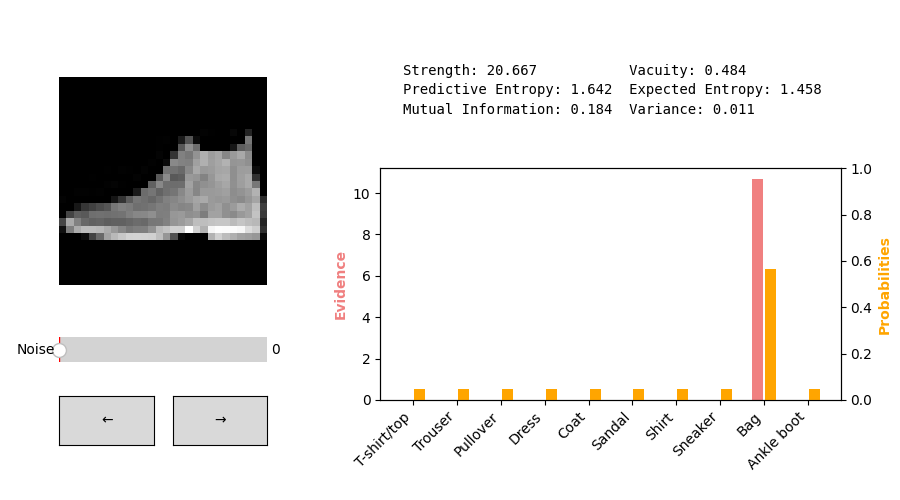

In [18]:
dataiter = iter(fashion_loader_test)
images, _ = next(dataiter)

plt.close()
browser = EDLBrowser(images, model_edl, class_names=fashion_classes, with_noise=True)

### Testing on Out-of-Distribution Data

In this final check, we evaluate the EDL model on CIFAR-10 images, which are out-of-distribution relative to FashionMNIST.

As you browse samples, pay attention to three signals:

- **Predicted class probabilities**: are predictions still sharply peaked?
- **Total evidence / vacuity**: does uncertainty increase on unfamiliar inputs?
- **Consistency across samples**: does the model stay cautious or become overconfident on specific patterns?

A desirable OOD behavior is lower evidence and higher uncertainty compared with in-distribution test images, even when a top class is still selected.

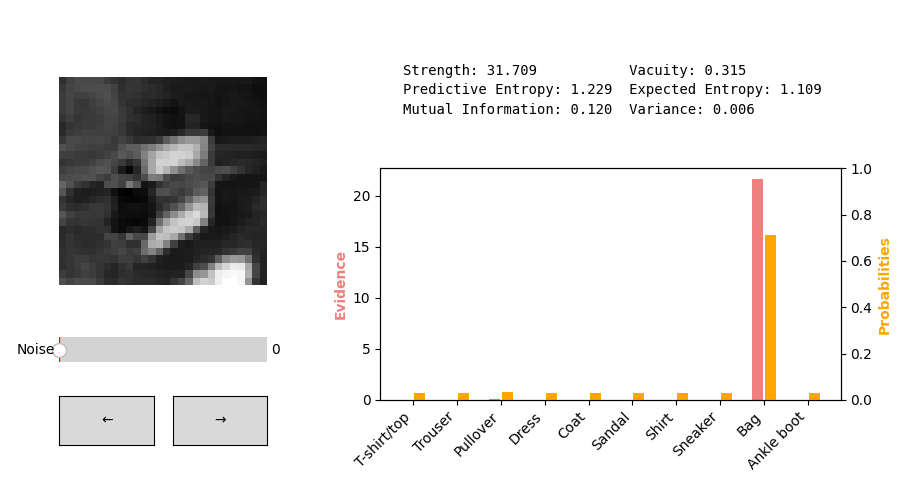

In [12]:
dataiter = iter(cifar_loader_test)
images, _ = next(dataiter)

plt.close()
browser = EDLBrowser(images, model_edl, class_names=fashion_classes, with_noise=True)